2025-11-25. Demo of restructured mass spectrum simulation project

This notebook tests my scripts for a small subset of the molecules in my real dataset. 
In the future, we can use this for a workflow demo. 

In [1]:
import os
import subprocess
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Remove duplicates from dataset and write smiles in canonical form. Output: A list of SMILES to use as input for derivitization. 

In [2]:
! . ~/.bashrc
!echo $SCRIPTS_NEIMS/processing

/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing


In [5]:
%run /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/remove_duplicate_SMILES_entries.py -i ../data/raw/franklin/goamazon.csv -o ../data/processed/franklin/dataset_unique.csv --index_map_file ../data/processed/franklin/duplicate_mapping.csv  --log_file ../data/processed/franklin/dataset_duplicates.csv


Saved 61 unique molecules to ../data/processed/franklin/dataset_unique.csv
Saved duplicate mapping to ../data/processed/franklin/dataset_duplicates.csv
Saved old->new index mapping to ../data/processed/franklin/duplicate_mapping.csv


## 2.1 Derivatize molecules. Output: A list of derivatized SMILES for input to MS simulations

<Figure size 2000x1500 with 0 Axes>

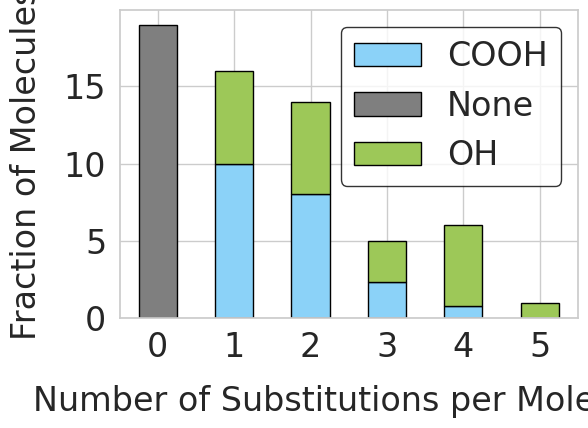


Percentage of equality: 95.08%

Mismatched rows:
Index 7: s1 = 1, s2 = 0.0, SMILES s1 = C[Si](C)(C)OC1=CC=CC=C1C(=O)OC1CC(C)CC(C)(C)C1, SMILES s2 = CC1CC(OC(=O)C2=CC=CC=C2O)CC(C)(C)C1
Index 26: s1 = 1, s2 = 0.0, SMILES s1 = C[Si](C)(C)OC1=CC(OC)=CC(OC)=C1C(C)=O, SMILES s2 = COC1=CC(OC)=C(C(C)=O)C(O)=C1
Index 58: s1 = 2, s2 = 0.0, SMILES s1 = C[Si](C)(C)OC(=O)C1=CC=CC=C1C(=O)O[Si](C)(C)C, SMILES s2 = O=C(O)C1=CC=CC=C1C(=O)O


In [7]:
%run /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/make_TMS_derivative_251125_v1.py --compare_ref \
    -i ../data/processed/franklin/franklin_unique.csv \
    -o ../data/processed/franklin_tms/franklin_TMS.csv


## 3. Make molecule folders and run sdf from smiles

In [5]:
%run /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/make_directories_and_sdfs.py  --input_csv ../data/processed/franklin_tms/franklin_TMS.csv --output_root ../data/simulation_results/franklin_tms/QCxMS_10_ps


[EXISTING] Folder exists: 0000
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0001
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0002
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0003
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0004
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0005
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0006
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0007
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTIN

In [6]:
%run /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/make_directories_and_sdfs.py  --input_csv ../data/processed/franklin_tms/franklin_TMS.csv --output_root ../data/simulation_results/franklin_tms/QCxMS_25_ps


[EXISTING] Folder exists: 0000
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0001
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0002
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0003
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0004
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0005
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0006
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0007
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTIN

## 4.1 Run the initial QCxMS ground state optimization and MD

In [7]:
# Paths
sim_dir = os.path.abspath(os.path.join(
    os.getcwd(),
    "../data/simulation_results/franklin_tms/QCxMS_25_ps/"
))
script_path = os.path.abspath(os.path.join(
    sim_dir,
    "../../../../src/workflow/submit_qcxms_gs_md_25_ps.sh"  # adjust as needed
))

# Create directory if it doesn't exist
os.makedirs(sim_dir, exist_ok=True)
print(f"Using simulation directory: {sim_dir}")

# Submit SLURM job
result = subprocess.run(
    ["sbatch", "--array=0-61", script_path],
    cwd=sim_dir,  # run from the simulation directory
    capture_output=True,
    text=True
)

# Print SLURM output
print(result.stdout)
print(result.stderr)

Using simulation directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_25_ps
Submitted batch job 31275643




In [8]:
# Paths
sim_dir = os.path.abspath(os.path.join(
    os.getcwd(),
    "../data/simulation_results/franklin_tms/QCxMS_10_ps/"
))
script_path = os.path.abspath(os.path.join(
    sim_dir,
    "../../../../src/workflow/submit_qcxms_gs_md_10_ps.sh"  # adjust as needed
))

# Create directory if it doesn't exist
os.makedirs(sim_dir, exist_ok=True)
print(f"Using simulation directory: {sim_dir}")

# Submit SLURM job
result = subprocess.run(
    ["sbatch", "--array=0-61", script_path],
    cwd=sim_dir,  # run from the simulation directory
    capture_output=True,
    text=True
)

# Print SLURM output
print(result.stdout)
print(result.stderr)

Using simulation directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_10_ps
Submitted batch job 31275712




## 4.2 Run QCxMS fragmentation script for each molecule

In [1]:
import os
import subprocess

# Root simulation directory
sim_dir = "../data/simulation_results/franklin_tms/QCxMS_25_ps"
script_path = os.path.abspath(
    os.path.join(sim_dir, "../../../../src/workflow/submit_qcxms_frag_serial_no_unity.sh")
)

for i in range(0, 61):  # 0000 to 0060 inclusive
    mol = f"{i:04d}"
    mol_path = os.path.join(sim_dir, mol, "GS-opt", "MS-run")

    if not os.path.isdir(mol_path):
        print(f"Skipping {mol}, QCxMS/GS-opt folder not found")
        continue

    result = subprocess.run(
        ["bash", script_path],
        cwd=mol_path,
        capture_output=True,
        text=True
    )

    print(f"Submitted {mol}:")
    print(result.stdout)
    print(result.stderr)


Submitted 0000:
Ground-state run completed successfully: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_25_ps/0000/GS-opt/MS-run/qcxms.out
Starting parallel QCxMS run on /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_25_ps/0000/GS-opt/MS-run/TMPQCXMS
Detected atom count: 52
Skipping TMP.1 (already finished successfully)
Skipping TMP.10 (already finished successfully)
Skipping TMP.100 (already finished successfully)
Skipping TMP.1000 (already finished successfully)
Skipping TMP.1001 (already finished successfully)
Skipping TMP.1002 (already finished successfully)
Skipping TMP.1003 (already finished successfully)
Skipping TMP.1004 (already finished successfully)
Skipping TMP.1005 (already finished successfully)
Skipping TMP.1006 (already finished successfully)
Skipping TMP.1007 (already finished successfully)
Skipping TMP.1008 (already finished successfully)
Skipp

In [2]:
import os
import subprocess

# Root simulation directory
sim_dir = "../data/simulation_results/franklin_tms/QCxMS_10_ps"
script_path = os.path.abspath(
    os.path.join(sim_dir, "../../../../src/workflow/submit_qcxms_frag_serial_no_unity.sh")
)

for i in range(0, 61):  # 0000 to 0060 inclusive
    mol = f"{i:04d}"
    mol_path = os.path.join(sim_dir, mol, "GS-opt", "MS-run")

    if not os.path.isdir(mol_path):
        print(f"Skipping {mol}, QCxMS/GS-opt folder not found")
        continue

    result = subprocess.run(
        ["bash", script_path],
        cwd=mol_path,
        capture_output=True,
        text=True
    )

    print(f"Submitted {mol}:")
    print(result.stdout)
    print(result.stderr)


Submitted 0000:
Ground-state run completed successfully: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_10_ps/0000/GS-opt/MS-run/qcxms.out
Starting parallel QCxMS run on /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_10_ps/0000/GS-opt/MS-run/TMPQCXMS
Detected atom count: 52
TOTAL = 1300 directories to process
Submitting array job with 5 tasks (up to 300 dirs per task)
Submitted batch job 31375277
Submitted array job of 5 tasks for 1300 directories


Submitted 0001:
Ground-state run completed successfully: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_10_ps/0001/GS-opt/MS-run/qcxms.out
Starting parallel QCxMS run on /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/QCxMS_10_ps/0001/GS-opt/MS-run/TMPQCXMS
Detected atom count: 37
TOTAL = 925 directo

## 4.3 Run QCxMS postprocessing: check that number of successful frag. runs was more than 90 %,
## and generate a raw spectra (unfiltered, with floats for m/z numbers)

## 5.1 Run NEIMS for each molecule using the unoptimized SDF (doesnt care of 3D geom)

In [3]:
%run /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/make_directories_and_sdfs.py  --input_csv ../data/processed/franklin_tms/franklin_TMS.csv --output_root ../data/simulation_results/franklin_tms/NEIMS

[EXISTING] Folder exists: 0000
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0001
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0002
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0003
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0004
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0005
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0006
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTING] Folder exists: 0007
  → SMILES file exists, skipping
  → SDF exists, skipping
  → metadata.json exists, skipping
[EXISTIN

In [4]:


# -----------------------------
# Configuration
# -----------------------------

sim_dir = os.path.abspath(os.path.join(
    os.getcwd(),
    "../data/simulation_results/franklin_tms/NEIMS/"
))
script_path = os.path.abspath(os.path.join(
    sim_dir,
    "../../../../src/workflow/submit_neims_array.sh"  # adjust as needed
))

# Create directory if it doesn't exist
os.makedirs(sim_dir, exist_ok=True)
print(f"Using simulation directory: {sim_dir}")

# Submit SLURM job
result = subprocess.run(
    ["sbatch", "--array=0-1", script_path],
    cwd=sim_dir,  # run from the simulation directory
    capture_output=True,
    text=True
)



# -----------------------------
# Output
# -----------------------------
if result.returncode != 0:
    print("Submission failed:")
    print(result.stderr)
else:
    print("SLURM submission output:")
    print(result.stdout)


Using simulation directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/franklin_tms/NEIMS
SLURM submission output:
Submitted batch job 31295520



## 5.2 Run CFM-ID for compounds it is valid for 

## 6.1 Create a folder with dataset without duplicates and their experimental spectra

In [ ]:
%run /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/copy_unique_folders.py -m ../data/processed/toy_data/duplicate_mapping.csv -s ../data/raw/exp_ms/toy_tms -o ../data/processed/exp/toy_tms_unique


## 6.2 Compare NEIMS and QCxMS spectra to eachother and to the reference spectra (choices, binning all peaks to closest integer, then removing peaks with X % of base peak intensity)

## 6.3 Test only using 20 most strong signals 

## 7. Plot results